<a href="https://www.kaggle.com/code/arnav967/wattsstrogatz-graph?scriptVersionId=315153787" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

Simulating for p=0...
Simulating for p=0.05...
Simulating for p=0.2...
Simulating for p=1...


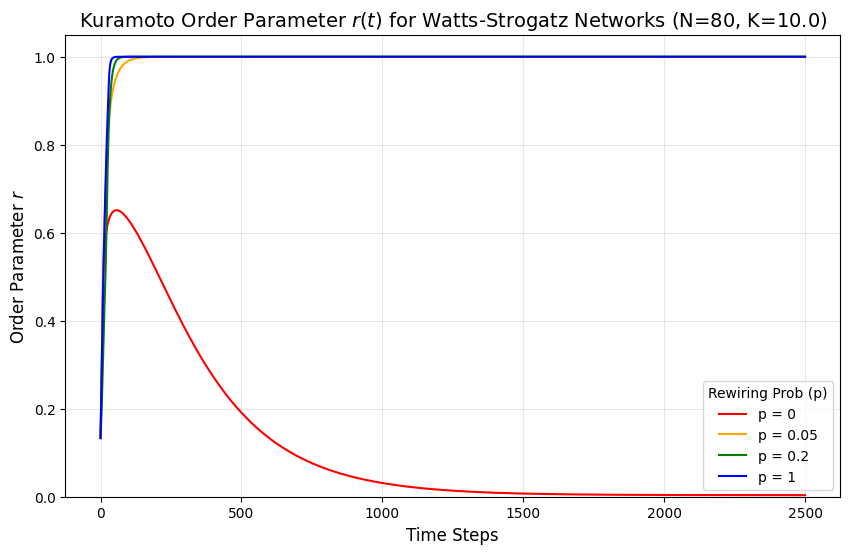

In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd

def simulate_kuramoto_ws(N=80, k=4, p=0.1, K=10.0, steps=2000, dt=0.05, seed=42):
    
    G = nx.watts_strogatz_graph(n=N, k=k, p=p, seed=seed)
    
    
    np.random.seed(seed)
    theta = np.random.uniform(0, 2*np.pi, N)
    omega = 2.0 + np.random.uniform(-0.02, 0.02, N)
    
    r_history = []
    
    for _ in range(steps):
       
        r = np.abs(np.mean(np.exp(1j * theta)))
        r_history.append(r)
        
       
        d_theta = np.zeros(N)
        for i in G.nodes():
            neighbors = list(G.neighbors(i))
            if neighbors:
                coupling = sum(np.sin(theta[j] - theta[i]) for j in neighbors) / k
                d_theta[i] = omega[i] + (K * coupling)
            else:
                d_theta[i] = omega[i]
        
       
        theta += d_theta * dt
        
    return r_history


N = 80
k = 4
K = 10.0
steps = 2500
dt = 0.05
p_values = [0, 0.05, 0.2, 1]
colors = ['red', 'orange', 'green', 'blue']

results = {}
plt.figure(figsize=(10, 6))

for p, color in zip(p_values, colors):
    print(f"Simulating for p={p}...")
    r_hist = simulate_kuramoto_ws(N=N, k=k, p=p, K=K, steps=steps, dt=dt)
    results[f'p={p}'] = r_hist
    plt.plot(r_hist, label=f'p = {p}', color=color)

plt.title(f"Kuramoto Order Parameter $r(t)$ for Watts-Strogatz Networks (N={N}, K={K})", fontsize=14)
plt.xlabel("Time Steps", fontsize=12)
plt.ylabel("Order Parameter $r$", fontsize=12)
plt.legend(title="Rewiring Prob (p)")
plt.grid(True, alpha=0.3)
plt.ylim(0, 1.05)
plt.savefig('kuramoto_r_vs_t_ws.png')
